In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score


In [9]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (important for regularization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


In [10]:
def evaluate_model(model, X_train, X_val, y_train, y_val):
    model.fit(X_train, y_train)

    # Predictions
    train_prob = model.predict_proba(X_train)
    val_prob = model.predict_proba(X_val)

    # Loss
    train_loss = log_loss(y_train, train_prob)
    val_loss = log_loss(y_val, val_prob)

    # Accuracy
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    # Weights
    weights = model.coef_.flatten()

    return train_loss, val_loss, train_acc, val_acc, weights



Baseline Model (No Regularization)

In [13]:
baseline_model = LogisticRegression(
    penalty=None,
    solver='lbfgs',
    max_iter=5000
)


baseline_results = evaluate_model(
    baseline_model, X_train, X_val, y_train, y_val
)

baseline_train_loss, baseline_val_loss, baseline_train_acc, baseline_val_acc, baseline_weights = baseline_results

print("Baseline Model")
print("Train Loss:", baseline_train_loss)
print("Validation Loss:", baseline_val_loss)
print("Train Accuracy:", baseline_train_acc)
print("Validation Accuracy:", baseline_val_acc)
print("Weight Magnitude (mean):", np.mean(np.abs(baseline_weights)))


Baseline Model
Train Loss: 0.00017713665366675505
Validation Loss: 1.9962744443928955
Train Accuracy: 1.0
Validation Accuracy: 0.9385964912280702
Weight Magnitude (mean): 108.24735601777918


L1 Regularization (Lasso)


In [14]:
l1_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=1.0,
    max_iter=5000
)

l1_results = evaluate_model(
    l1_model, X_train, X_val, y_train, y_val
)

l1_train_loss, l1_val_loss, l1_train_acc, l1_val_acc, l1_weights = l1_results

num_zero_weights = np.sum(l1_weights == 0)

print("\nL1 Regularization")
print("Train Loss:", l1_train_loss)
print("Validation Loss:", l1_val_loss)
print("Train Accuracy:", l1_train_acc)
print("Validation Accuracy:", l1_val_acc)
print("Zero Weights:", num_zero_weights)



L1 Regularization
Train Loss: 0.05368078545270136
Validation Loss: 0.06882399716112388
Train Accuracy: 0.9868131868131869
Validation Accuracy: 0.9649122807017544
Zero Weights: 15


L2 Regularization (Ridge)


In [15]:
l2_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    C=1.0,
    max_iter=5000
)

l2_results = evaluate_model(
    l2_model, X_train, X_val, y_train, y_val
)

l2_train_loss, l2_val_loss, l2_train_acc, l2_val_acc, l2_weights = l2_results

print("\nL2 Regularization")
print("Train Loss:", l2_train_loss)
print("Validation Loss:", l2_val_loss)
print("Train Accuracy:", l2_train_acc)
print("Validation Accuracy:", l2_val_acc)
print("Mean Weight Magnitude:", np.mean(np.abs(l2_weights)))



L2 Regularization
Train Loss: 0.05433742571095533
Validation Loss: 0.06012955060644868
Train Accuracy: 0.9868131868131869
Validation Accuracy: 0.9736842105263158
Mean Weight Magnitude: 0.580192178307878


Elastic Net Regularization


In [16]:
elastic_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    C=1.0,
    l1_ratio=0.5,
    max_iter=5000
)

elastic_results = evaluate_model(
    elastic_model, X_train, X_val, y_train, y_val
)

elastic_train_loss, elastic_val_loss, elastic_train_acc, elastic_val_acc, elastic_weights = elastic_results

print("\nElastic Net")
print("Train Loss:", elastic_train_loss)
print("Validation Loss:", elastic_val_loss)
print("Train Accuracy:", elastic_train_acc)
print("Validation Accuracy:", elastic_val_acc)
print("Zero Weights:", np.sum(elastic_weights == 0))



Elastic Net
Train Loss: 0.05494017742346613
Validation Loss: 0.06238869356418738
Train Accuracy: 0.9868131868131869
Validation Accuracy: 0.9736842105263158
Zero Weights: 5


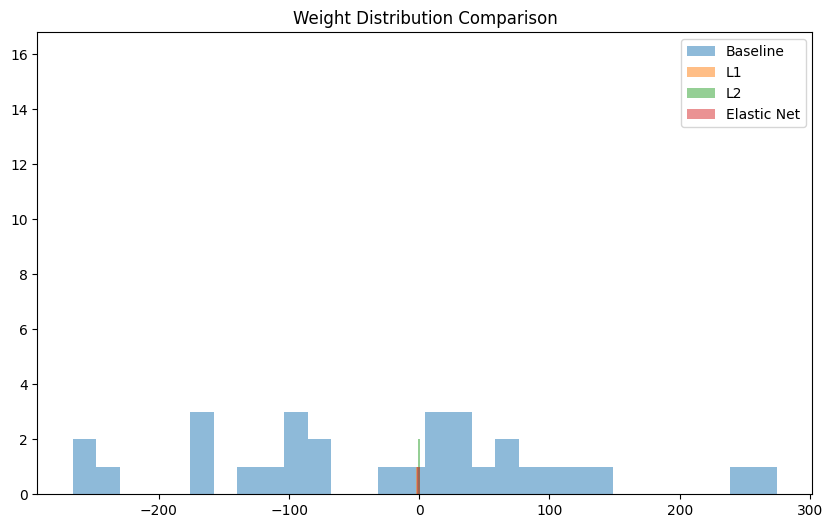

In [17]:
plt.figure(figsize=(10,6))
plt.hist(baseline_weights, bins=30, alpha=0.5, label="Baseline")
plt.hist(l1_weights, bins=30, alpha=0.5, label="L1")
plt.hist(l2_weights, bins=30, alpha=0.5, label="L2")
plt.hist(elastic_weights, bins=30, alpha=0.5, label="Elastic Net")
plt.legend()
plt.title("Weight Distribution Comparison")
plt.show()


In [18]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "L1", "L2", "Elastic Net"],
    "Train Accuracy": [baseline_train_acc, l1_train_acc, l2_train_acc, elastic_train_acc],
    "Validation Accuracy": [baseline_val_acc, l1_val_acc, l2_val_acc, elastic_val_acc],
    "Train Loss": [baseline_train_loss, l1_train_loss, l2_train_loss, elastic_train_loss],
    "Validation Loss": [baseline_val_loss, l1_val_loss, l2_val_loss, elastic_val_loss],
    "Zero Weights": [
        0,
        np.sum(l1_weights == 0),
        0,
        np.sum(elastic_weights == 0)
    ]
})

comparison


,Model,Train Accuracy,Validation Accuracy,Train Loss,Validation Loss,Zero Weights
0,Baseline,1.000000,0.938596,0.000177,1.996274,0
1,L1,0.986813,0.964912,0.053681,0.068824,15
2,L2,0.986813,0.973684,0.054337,0.060130,0
3,Elastic Net,0.986813,0.973684,0.054940,0.062389,5


Advanced Task – Hyperparameter Sensitivity

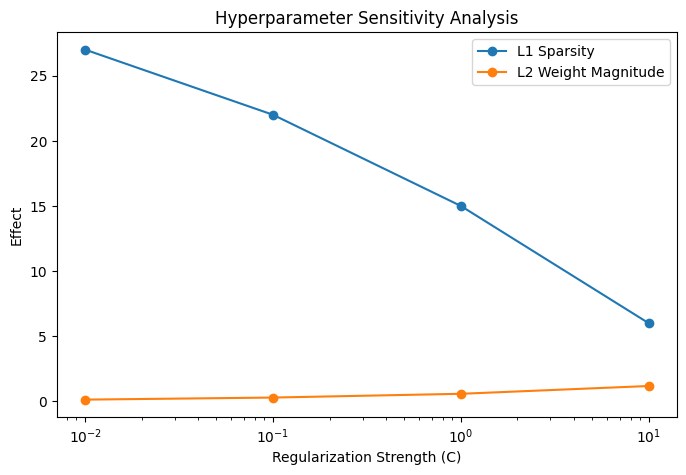

In [19]:
C_values = [0.01, 0.1, 1, 10]
l1_sparsity = []
l2_weight_mag = []

for C in C_values:
    l1 = LogisticRegression(penalty='l1', solver='saga', C=C, max_iter=5000)
    l1.fit(X_train, y_train)
    l1_sparsity.append(np.sum(l1.coef_ == 0))

    l2 = LogisticRegression(penalty='l2', solver='lbfgs', C=C, max_iter=5000)
    l2.fit(X_train, y_train)
    l2_weight_mag.append(np.mean(np.abs(l2.coef_)))

plt.figure(figsize=(8,5))
plt.plot(C_values, l1_sparsity, marker='o', label="L1 Sparsity")
plt.plot(C_values, l2_weight_mag, marker='o', label="L2 Weight Magnitude")
plt.xscale("log")
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Effect")
plt.legend()
plt.title("Hyperparameter Sensitivity Analysis")
plt.show()
